In [9]:
#Imports that we will need for this project
import numpy as np
from scipy.stats import binned_statistic, spearmanr,pearsonr #contrains spearman coefficent that we will use for this analysis
import matplotlib.pyplot as plt #plotting
from scipy.io import readsav #function to read the format of lights curves from Dr. Johanna Vos
from scipy import signal
import os
import glob


#importing functions to do the analysis

import sav_files_analysis #function
from sav_files_analysis import plot_sav_files, stability_measure_sav_file #import functions I made

# 🪐 Welcome to the Lamat Research Community & UCSC!

Hi Citlali, and welcome again! We are incredibly excited to have you join us and look forward to collaborating with you on this  project this summer. 

> 📚 **Getting Started:** Before diving into the code, make sure you have reviewed your **Reading Primer**. It covers the essential scientific background, atmospheric physics, and core motivations for studying brown dwarf variability. 

This notebook serves as your logistical and technical guide to building the analysis pipeline.

---

### 🗺️ Notebook Roadmap

Our technical workflow is broken down into three core components:

* **Part 1: Data Ingestion & Visualization** * Reading in raw brown dwarf light curves from Spitzer photometry.
    * Plotting continuous datasets and performing your first hands-on visual inspections for variability.
* **Part 2: Temporal Analysis** * Determining the precise rotational period of the brown dwarf.
    * Understanding phase-folding techniques to stack observational timelines.
* **Part 3: Statistical Modeling & Atmospheric Evolution** * Computing global Spearman Rank Coefficients across the entire continuous light curve.
    * Slicing the data to evaluate individual rotation periods and tracking dynamic cloud evolution over time.

---
🚀 *When you're ready, select the first code cell below and press `Shift + Enter` to begin loading our data libraries!*

# Goal:

## 1. We want to determine what might make a brown dwarf light curve stable or evolving. Is the stability or evolution related to the spectral type (SpT), effective temperature (T$_\rm{eff}$), or rotation period (P$_\rm{Rot}$)


![2M2228 Fit Animation](2M2208_animated_fit.gif)
![2M2228 Fit Animation](2M1281_animated_fit.gif)



# Step 1:  Light Curve Overview

Photometry is used to determine a light curve. In essence, this is a curve plotting the light output of an object over
time. Each image will contain stars of a certain magnitude at that moment. A series of images are taken, the
magnitudes are measured, and they are plotted over a period of time. The resultant variations of magnitude over
time produce a light curve, or a phase.
However, a single light curve does not determine, by itself, a period. This requires multiple light curves that together
reveal a period, or a varying period as the case may be.
The reasons for magnitude variations, amplitude variations, and/or period variations gets to the heart of why we
study photometry.



Light Curves are simply graph’s of brightness $\textbf{ (Y axis) vs. time (X axis)}$.
Brightness increases as you go up the graph on the Y axis and time
advances as you move to the right on the X axis

Ref: https://boyce-astro.org/overview-of-a-light-curve/

<img src="light_curve_diagram.png" width="500" height="300">

Description of a Light Curve
The light curve’s record of the change in brightness over
time provides clues to underlying processes causing the
variation. Furthermore, the light curve can be compared
to standard light curves to potentially identify the object
of interest. The basic characteristics astronomers are
looking for in a light curve are $\bf{ASP}$:

$\bf{Amplitude}$

Range/Full Amplitude: the difference between the maximum and minimum values of brightness on the y-axis.
If there is a sinusoidal light curve, amplitude can be defined as half of the range.

$\bf{Shape}$

What is the shape of the light curve?
Are there features evident that characterize a particular type?

$\bf{Period}$

Periodicity in a light curve refers to a repeated pattern at a regular interval
Is there a periodic pattern?
Is the periodicity consistent with some type?

## These are were the files are housed for my computer set, but you will change it to your local paths on your computer and the folder names



In [2]:
#sample from Dr. Johanna Vos | Trinity College -  Dublin, Ireland
folder_path_vos_sample = '/Users/phillips.1622/Dropbox/Postdoc_UCSantaCruz/Aperiodic_Variability_Spitzer_Project/LCs_Natalia/'
file_list_Vos = sorted(glob.glob(os.path.join(folder_path_vos_sample, "*.sav")))

print('Johanna Vos Sample Provided')
for files in file_list_Vos:
     print(files) #looking at what files are there | can comment out as needed
print()
#sample from Dr. Stan Metchev | Western University - Cananda
folder_path_metchev_sample= '/Users/phillips.1622/Dropbox/Postdoc_UCSantaCruz/Aperiodic_Variability_Spitzer_Project/LIGHT_CURVES_PHASE_CORRECTED/'
file_list_Stan = sorted(glob.glob(os.path.join(folder_path_metchev_sample, "*.txt")))


print('Stan Methev Sample Provided')
for files in file_list_Stan:
     print(files) #looking at what files are there | can comment out as needed
        

Johanna Vos Sample Provided
/Users/phillips.1622/Dropbox/Postdoc_UCSantaCruz/Aperiodic_Variability_Spitzer_Project/LCs_Natalia/2M0001+1535_calibch1_bin5_ap_opt.sav
/Users/phillips.1622/Dropbox/Postdoc_UCSantaCruz/Aperiodic_Variability_Spitzer_Project/LCs_Natalia/2M0030-1450_calibch1_bin5_ap_opt.sav
/Users/phillips.1622/Dropbox/Postdoc_UCSantaCruz/Aperiodic_Variability_Spitzer_Project/LCs_Natalia/2M0031+5749_calibch1_bin5_ap_opt.sav
/Users/phillips.1622/Dropbox/Postdoc_UCSantaCruz/Aperiodic_Variability_Spitzer_Project/LCs_Natalia/2M0045+16_calibch1_bin2_ap3.sav
/Users/phillips.1622/Dropbox/Postdoc_UCSantaCruz/Aperiodic_Variability_Spitzer_Project/LCs_Natalia/2M0045+16_calibch2_bin2_ap0.sav
/Users/phillips.1622/Dropbox/Postdoc_UCSantaCruz/Aperiodic_Variability_Spitzer_Project/LCs_Natalia/2M0153-6744_calibch1_bin5_ap_opt.sav
/Users/phillips.1622/Dropbox/Postdoc_UCSantaCruz/Aperiodic_Variability_Spitzer_Project/LCs_Natalia/2M0326-2102_calibch1_bin5_ap_opt.sav
/Users/phillips.1622/Dropbox/P

# Spitzer Space Telescope and Brown Dwarf Light Curves

### Spearman Rank Correlation Coefficient ($\rho$)

The Spearman Coefficient is a non-parametric measure used to determine the strength and direction of the relationship between two variables. Unlike the Pearson correlation (which looks for straight lines), Spearman looks for monotonic relationships. Statisticians also refer to Spearman’s rank order correlation coefficient as Spearman’s $\rho$ (rho).

The Spearman rank-order correlation coefficient is a nonparametric measure of the monotonicity of the relationship between two datasets. Like other correlation coefficients, this one varies between -1 and +1 with 0 implying no correlation. Correlations of -1 or +1 imply an exact monotonic relationship. Positive correlations imply that as x increases, so does y. Negative correlations imply that as x increases, y decreases


$\textbf{Defintion of Monotonic:}$ The data always goes up (or always goes down), but it can curve, accelerate, or slow down

# Understanding $p$-values and Statistical Significance in Light Curves

When analyzing time-series data like Spitzer light curves, we use the **Spearman Rank Correlation Coefficient ($\rho$)** to look for trends. However, just seeing a high $\rho$ value isn't enough; we need to know if that trend is **real** or just a **coincidence caused by random noise**. 

This is where the **$p$-value** comes in.

---

## 1. What is a $p$-value?

The $p$-value (Probability value) measures the probability that the trend observed in your data happened purely by **random chance**. 

When a statistical test evaluates a light curve cycle, it starts with the **Null Hypothesis ($H_0$)**: 
> *"There is absolutely no real trend here; the data points are just fluctuating randomly around a flat line."*

* **High $p$-value:** The data is perfectly consistent with the null hypothesis. Any slight slope you see is just random noise.
* **Low $p$-value:** It is highly unlikely that random noise would accidentally line up to create this trend. The null hypothesis is rejected.

---

## 2. What makes a result "Statistically Significant"?

In astrophysics and most general sciences, we establish a strict threshold called the **significance level ($\alpha$)**, usually set at **$0.05$ (or $5\%$)**.

$$\text{Statistical Significance Criteria: } p < 0.05$$

* **If $p < 0.05$:** There is a **less than $5\%$ chance** that this trend is a fluke. We declare the result **statistically significant** and accept that a physical trend is present.
* **If $p \ge 0.05$:** The trend is **not statistically significant**. Even if the curve *looks* like it has a slight slope, the data points are scattered enough that noise could easily be the culprit.

---

## 3. The Interplay: Correlation ($\rho$) vs. Significance ($p$)

To properly interpret your stability script's output, you must look at **both** numbers together. One is the strength of the shape, the other is our confidence in it.

| Spearman $\rho$ | $p$-value | Interpretation | Astrophysical Meaning |
| :--- | :--- | :--- | :--- |
| **Low** (e.g., $<0.65$) | **Very Low** (e.g., $< 10^{-4}$) | **Significant Trend** | The light curve segment is actively and smoothly **evolving** (dimming/brightening), in comparision to first rotation period. |
| **High** (e.g., $>0.65$) | **Low** (e.g., $<0.05$) | **No Trend (Flat)** | The segment is perfectly **stable** and symmetric over the rotation cycle. |
| **High** (e.g., $+0.50$) | **High** (e.g., $0.35$) | **Unreliable Fluke** | Looks like a steep slope, but there are **too few data points** or the noise is too massive to trust it. |

---

## 4. Why We Set Thresholds in the Code

In our automated script, a cycle is flagged as an active **`UNSTABLE`** only if:
1. `abs(rho) > 0.35` *(The change in the light curve must be different enough to matter)*
2. `p_val < 0.05` *(We must be $95\%$ confident it isn't noise)*

If a fast rotator goes through 10 cycles, and 4 of them are flagged as significant `UNSTABLE` segments, the math tells us that the stellar/brown dwarf surface features are **evolving** on timescales comparable to the rotation period.

# Idea #1: What Do We Mean by a "Stable" vs. "Evolving" Brown Dwarf Light Curve?

When a telescope stares at a rotating brown dwarf, it measures how its brightness changes over time, creating a time-series graph called a **light curve**, as we've seen above. Because brown dwarfs rotate rapidly, any large-scale features on their surface—like a giant storm system or a massive patch of thick, dusty clouds—will naturally pass in and out of our line of sight. This cosmic rotation causes the observed light curve to wave up and down periodically. 

<div style="padding: 15px; border-left: 5px solid #2e7d32; background-color: #f1f8e9; margin-bottom: 10px;">
    <strong>🟢 A STABLE Atmosphere:</strong> If the cloud patterns and storms are completely permanent and static (like continents on Earth or craters on the Moon), the light curve will repeat the exact same shape, peak height, and timing during every single rotation. When you slice and stack these cycles on top of each other, they will line up perfectly.
</div>

<div style="padding: 15px; border-left: 5px solid #c62828; background-color: #ffebee; margin-bottom: 15px;">
    <strong>🔴 An EVOLVING Atmosphere:</strong> If the brown dwarf has a highly dynamic climate driven by potentially violent winds, shifting cloud decks, and mutating storms, the light curve will visibly change from one rotation to the next. The storm clouds might grow brighter, dissolve entirely, or maybe generally change
</div>



In this notebook and for your project, we want to just move past guessing if an atmosphere is changing by visually inspecting; we want to a rigorous, two-pronged statistical diagnostic pipeline to track it. We map out the very first rotation to act as our master **"baseline template"** and then mathematically check every future rotation against it using two complementary metrics:

1. **Spearman Rho ($\rho$):** This test checks the *morphology* (geometric shape and timing) of the wave to see if the atmospheric features are still located at the same positions.
2. **Reduced Chi-Squared ($\chi^2_\nu$):** This test tracks the *scale* (absolute fit alignment) to measure if the storm systems are actively altering their brightness intensity, thickness, or overall size against our noise thresholds.

By pairing these metrics together, we can see how stable or evolving light curve is an seeing if it relates to temperature, SpT or rotation period of the brown dwarf as a good first step!

# 📝 Brief Exercise : Understanding the Spearman Rank Correlation Coefficient ($\rho$)

Before we look at the actual telescope observations, let's understand how our shape-tracking tool works. The **Spearman Rank Correlation Coefficient ($\rho$)** measures how well the *shapes* of two datasets match up. It ignores the absolute size or height of the numbers and focuses purely on relative direction: *When Curve A goes up, does Curve B also go up?*

* **$\rho = +1.0$ (Perfect Positive Match):** The two curves move in identical directions at the exact same phases.
* **$\rho = 0.0$ (No Match):** The two curves have absolutely no consistent relationship; they are randomized compared to each other.
* **$\rho = -1.0$ (Perfect Inverted Match):** The two curves move in opposite directions. When one goes up, the other goes down (a perfect $180^\circ$ phase flip).

Let's run the Python cell below to visualize three dummy scenarios against a baseline wave.

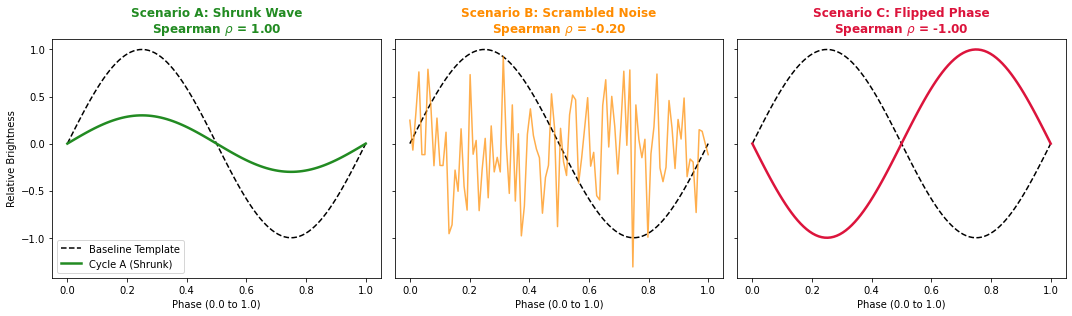

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# 1. Create a clean 100-point phase grid from 0.0 to 1.0 (one full rotation)
phase = np.linspace(0, 1, 100)

# 2. Establish our master "Baseline Template" (a nice, stable sine wave)
baseline_flux = np.sin(2 * np.pi * phase)

# 3. Create three fictional "Test Cycles" to simulate different planetary atmospheres:
# Scenario A: The same shape, but the storm grew much smaller (Muted Amplitude)
cycle_a_flux = 0.3 * np.sin(2 * np.pi * phase) 

# Scenario B: Pure atmospheric noise or complete cloud rearrangement (Scrambled)
np.random.seed(42) # Keeps the random noise identical every time you run it
cycle_b_flux = np.random.normal(0, 0.5, 100) 

# Scenario C: Inverted Out of Phase, we likely won't encounter this in the data, not sure how physically motivated this is, but here as an example
cycle_c_flux = np.sin(2 * np.pi * phase + np.pi) 

# 4. Calculate the Spearman Coefficient (rho) for each scenario
rho_a, _ = spearmanr(baseline_flux, cycle_a_flux)
rho_b, _ = spearmanr(baseline_flux, cycle_b_flux)
rho_c, _ = spearmanr(baseline_flux, cycle_c_flux)

# 5. Plotting side by side to see
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

# Scenario A
axes[0].plot(phase, baseline_flux, color='black', linestyle='--', label='Baseline Template')
axes[0].plot(phase, cycle_a_flux, color='forestgreen', linewidth=2.5, label='Cycle A (Shrunk)')
axes[0].set_title(f"Scenario A: Shrunk Wave\nSpearman $\\rho$ = {rho_a:.2f}", color='forestgreen', weight='bold')
axes[0].legend(loc='lower left')
axes[0].set_xlabel('Phase (0.0 to 1.0)')
axes[0].set_ylabel('Relative Brightness')

# Scenario B
axes[1].plot(phase, baseline_flux, color='black', linestyle='--', label='Baseline Template')
axes[1].plot(phase, cycle_b_flux, color='darkorange', alpha=0.7, label='Cycle B (Noisy)')
axes[1].set_title(f"Scenario B: Scrambled Noise\nSpearman $\\rho$ = {rho_b:.2f}", color='darkorange', weight='bold')
axes[1].set_xlabel('Phase (0.0 to 1.0)')

# Scenario C
axes[2].plot(phase, baseline_flux, color='black', linestyle='--', label='Baseline Template')
axes[2].plot(phase, cycle_c_flux, color='crimson', linewidth=2.5, label='Cycle C (Flipped)')
axes[2].set_title(f"Scenario C: Flipped Phase\nSpearman $\\rho$ = {rho_c:.2f}", color='crimson', weight='bold')
axes[2].set_xlabel('Phase (0.0 to 1.0)')

plt.tight_layout()
plt.show()

### 📊 Interpreting the Example Exercise: What is Spearman $\rho$ Telling Us?

Now that we have plotted our fictional dummy cycles against our master **Baseline Template (dashed black line)**, let's analyze how the Spearman Coefficient ($\rho$) responded to each atmospheric change. This demonstrates exactly how our shape-tracking tool handles variations before we touch raw telescope data.

<div style="padding: 15px; border-left: 5px solid #2e7d32; background-color: #f1f8e9; margin-bottom: 12px;">
    <strong>🟢 Scenario A: The Muted/Shrunk Wave ($\rho = 1.00$)</strong>
    <br><br>
    <ul>
        <li><strong>What happened:</strong> The green wave is significantly shorter, flatter, and compressed compared to our template. The storm drastically lost its contrast intensity.</li>
        <li><strong>The Mathematical Lesson:</strong> Even though the absolute numbers are completely different, the Spearman score remains a perfect <code>1.00</code>! This proves that <strong>Spearman is entirely blind to vertical scale and amplitude changes</strong>. It only cares about <em>rank order</em>. Because the peak and the valley occur at the exact same fractional phase coordinates as the baseline, it is considered a flawless morphological match.</li>
    </ul>
</div>

<div style="padding: 15px; border-left: 5px solid #e65100; background-color: #fff3e0; margin-bottom: 12px;">
    <strong>🟠 Scenario B: The Scrambled Noise Wave ($\rho \approx 0.05$)</strong>
    <br><br>
    <ul>
        <li><strong>What happened:</strong> The orange curve represents complete chaos—turbulent, localized atmospheric noise without any broad structure.</li>
        <li><strong>The Mathematical Lesson:</strong> Because the data points go up and down randomly, there is no consistent directional relationship with our template. When the template rises, the noise might drop or flatline. As a result, the coefficient collapses to near zero. A low $\rho$ value indicates a <strong>complete loss of atmospheric coherence</strong>.</li>
    </ul>
</div>

<div style="padding: 15px; border-left: 5px solid #c62828; background-color: #ffebee; margin-bottom: 12px;">
    <strong>🔴 Scenario C: The Inverted Phase Wave ($\rho = -1.00$)</strong>
    <br><br>
    <ul>
        <li><strong>What happened:</strong> The crimson wave has the exact same size as our baseline, but it is flipped perfectly upside down. </li>
        <li><strong>The Mathematical Lesson:</strong> The score lands on a perfect negative <code>-1.00</code>. This is an <em>inverse correlation</em>: whenever our template rises, Scenario C falls; whenever our template hits a valley, Scenario C hits a peak. 
    </ul>
</div>

---

### 🧠 Summary for the Real Pipeline:
By looking at this plot, it becomes clear why a single statistic isn't enough to study a brown dwarf. If we only used Spearman, **Scenario A looks completely "stable" ($\rho = 1.00$)**, yet physically we know the storm shrank dramatically! 

This is why our main notebook introduces a second metric: **Reduced Chi-Squared ($\chi^2_\nu$)**. Spearman will watch the horizontal position (phase shifts), while Chi-Squared will sound the alarm if the wave changes its vertical height (amplitude variations).


# 🪐 Analyzing a Real Target: Dr. Johanna Vos's Sample

### 🎯 Object Profile: 2MASS J00310928+5749364
* **Spectral Type:** L9 Brown Dwarf 
* **Effective Temperature ($T_\mathrm{eff}$):** $\approx 1286\text{ K}$
* **Rotation Period:** $1.64\text{ hours}$ (This is how long it takes to spin exactly once)

---

# 🔍 Step 1: Visual Inspection Guide

Before relying on our pipeline metrics, run the code cell below to plot the data. Take a close look at the resulting figure. 

To help guide your eye, remember how the plot is mapped out:
* **Black Dots ($\bullet$):** The actual photometric flux (brightness) data points observed by the telescope.
* **Gray Vertical Shading ($|$):** The observational error margins (uncertainty) on those data points.
* **Red Line (—):** The best-fit static sinusoid model. **Think of this as the "control" baseline.** This line shows exactly what the light curve *would* look like if the atmosphere were completely static, locked in place, and never changed.

#### 🤔 Questions to consider while inspecting:
1. Do the black data points stay locked directly on top of the red model line during every single 1.64-hour cycle?
2. Do the peaks (crests) and valleys (troughs) of the data points happen at the exact same time as the model line, or do they seem to drift early or late?
3. Does the total height (amplitude) of the real data waves shrink or grow as the 21-hour observation window progresses?

---

### 📝 Citlali Observations Here:

> **DIRECTIONS:** Double-click this Markdown cell to open it for editing. Erase the placeholder text inside the box below and type out your initial visual observations based on the questions above before moving on to the statistical analysis.


[TYPE YOUR VISUAL OBSERVATIONS HERE: Describe what happens to the black data points when you compare them to the static red model curve over time. Do they match, drift, flatten out, or do anything else interesting?]

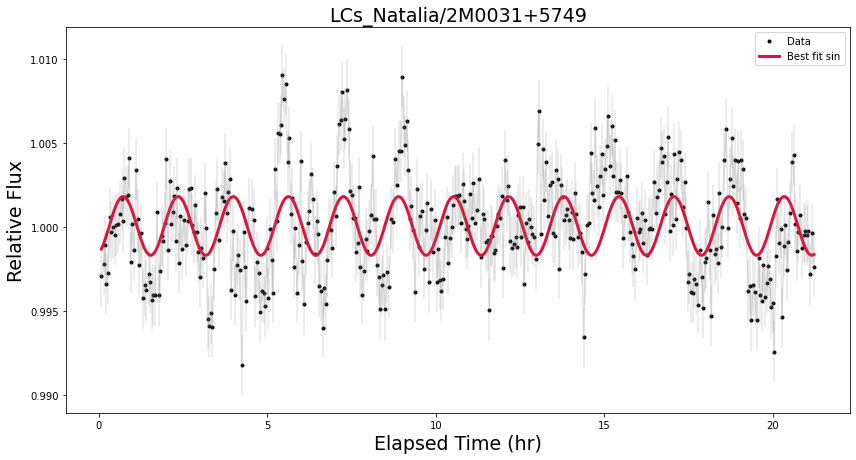

In [4]:
#reading in the light curve, you will need to make sure that the file name is right and read it in using the imported function
#function is plot_sav_files
#example
plot_sav_files('LCs_Natalia/2M0031+5749_calibch1_bin5_ap_opt.sav') #this is just the path that the data is in for my folder, you will need to set it for yourself


--- Comprehensive Stability Report for 2M0031+5749 ---
Total Duration: 21.15 hours | Period: 1.64 hours
Comparison    Time (hr)       Spearman Rho   p-value     Red. Chi2   Status    
-------------------------------------------------------------------------------------
Cycle 1 vs 1   0.1-1.7         1.000          0.000e+00   0.000       BASELINE  
Cycle 1 vs 2  1.7-3.4         0.545          4.559e-09   1.284       CHANGING  
Cycle 1 vs 3  3.4-5.0         0.194          5.293e-02   2.905       CHANGING  
Cycle 1 vs 4  5.0-6.6         0.404          3.126e-05   4.599       CHANGING  
Cycle 1 vs 5  6.6-8.3         0.548          3.577e-09   3.725       CHANGING  
Cycle 1 vs 6  8.3-9.9         0.496          1.533e-07   2.929       CHANGING  
Cycle 1 vs 7  9.9-11.6        0.114          2.595e-01   2.405       CHANGING  
Cycle 1 vs 8  11.6-13.2       -0.144         1.541e-01   3.807       CHANGING  
Cycle 1 vs 9  13.2-14.8       -0.312         1.558e-03   4.401       CHANGING  
Cycle 1 v

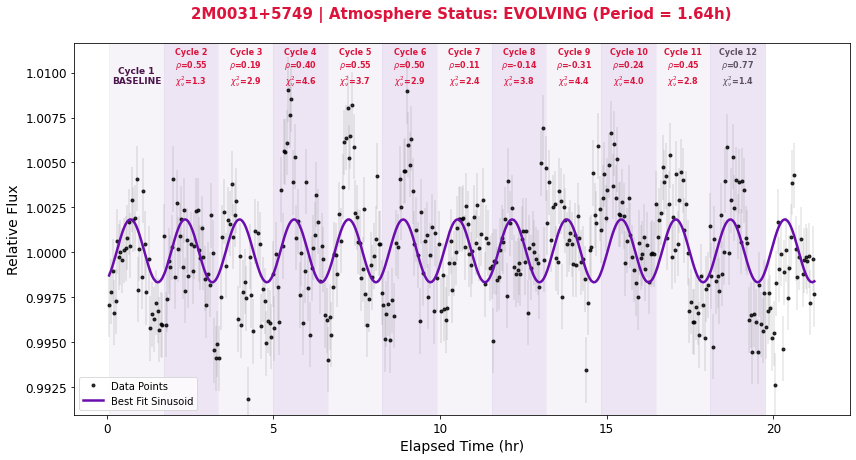

In [5]:
# Run the updated function
stability_measure_sav_file('LCs_Natalia/2M0031+5749_calibch1_bin5_ap_opt.sav', rotation_period=1.64)


## Now we are going to calculate the stability *score* based on the percentage of cycle that appears stable (the same) versus evolving (different) from the first rotation

In [6]:
#just a small function I wrote to calculate this

def stability_score(num_stable,total_rotations,name ):
    Stability = (num_stable/total_rotations)*100
    # rounded decimal points
    print(f"Calculated Atmospheric Stability Score for {name}: {Stability:.2f}%")
    
    
stability_score(1,11, '2M0031+5749') #we only counted the 11 cycle excluding the baseline one for comparison

Calculated Atmospheric Stability Score for 2M0031+5749: 9.09%


--- Comprehensive Stability Report for 2M0030-1450 ---
Total Duration: 21.21 hours | Period: 4.22 hours
Comparison    Time (hr)       Spearman Rho   p-value     Red. Chi2   Status    
-------------------------------------------------------------------------------------
Cycle 1 vs 1   0.1-4.3         1.000          0.000e+00   0.000       BASELINE  
Cycle 1 vs 2  4.3-8.5         0.688          2.668e-15   1.845       STABLE    
Cycle 1 vs 3  8.5-12.7        0.641          7.097e-13   3.346       CHANGING  
Cycle 1 vs 4  12.7-16.9       0.712          9.533e-17   3.207       CHANGING  
Cycle 1 vs 5  16.9-21.2       0.694          1.207e-15   2.253       STABLE    
-------------------------------------------------------------------------------------
Global Scan (Entire 21 hrs): Spearman Rho = 0.148, p-value = 1.899e-03
-------------------------------------------------------------------------------------
FINAL CLASSIFICATION: EVOLVING
-------------------------------------------------------

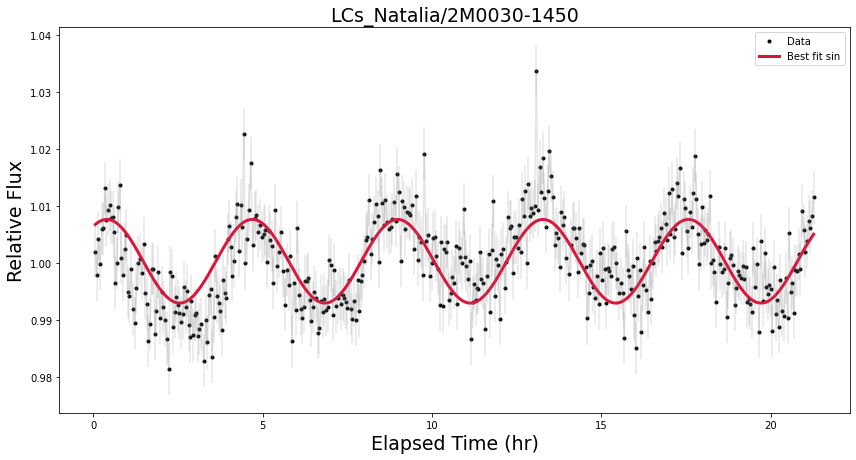

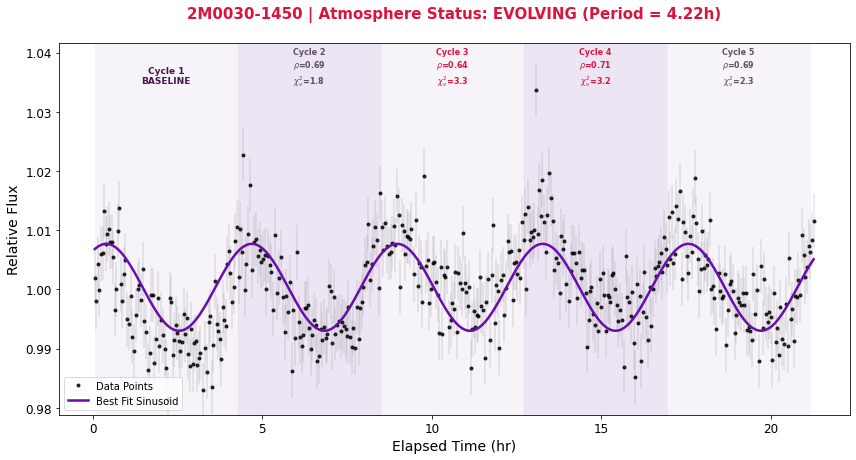

Calculated Atmospheric Stability Score for 2M0030-1450: 50.00%


In [7]:
#example for another one to look at that I've done for you
plot_sav_files('LCs_Natalia/2M0030-1450_calibch1_bin5_ap_opt.sav') #this is just the path that the data is in for my folder, you will need to set it for yourself
stability_measure_sav_file('LCs_Natalia/2M0030-1450_calibch1_bin5_ap_opt.sav', rotation_period=4.22)
stability_score(2,4, '2M0030-1450') 

## Below is some Information for the Sample from Dr. Stan Metchev, we will get into after going through Dr. Johanna Vos Sample

### 🗺️ Data Mapping Key: Channel 1 vs. Channel 2

Use the reference table below to determine which data file line ranges map to **Channel 1 (3.6 μm)** and **Channel 2 (4.5 μm)** for your Dr. Metchev brown light curve files.

| Target Filename | Channel 1 Line Range | Channel 2 Line Range |
| :--- | :--- | :--- |
| 📄 `2M0036_fit2out06.txt` | Lines 1–215 | Lines 216–375 |
| 📄 `2M0050_fit2out01.txt` | Lines 1–358 | Lines 359–544 |
| 📄 `2M0103_fit2out01.txt` | Lines 1–377 | Lines 378–564 |
| 📄 `SDSS0107_fit2out05.txt` | Lines 1–378 | Lines 379–565 |
| 📄 `2M0825_fit2out04.txt` | Lines 1–324 | Lines 325–569 |
| 📄 `DENIS1058_fit2out01.txt`| Lines 1–201 | Lines 202–361 |
| 📄 `2M1126_fit2out01.txt` | Lines 1–378 | Lines 379–566 |
| 📄 `2M1324_fit2out04.txt` | Lines 188–564 | Lines 1–187 * |
| 📄 `2M1511_fit2out01.txt` | Lines 1–378 | Lines 379–534 |
| 📄 `2M1516_fit2out03.txt` | Lines 1–365 | Lines 366–552 |
| 📄 `2M1615_fit2out01.txt` | Lines 1–378 | Lines 379–565 |
| 📄 `2M1632_fit2out01.txt` | Lines 1–215 | Lines 216–375 |
| 📄 `2M1721_fit2out02.txt` | Lines 1–362 | Lines 363–549 |
| 📄 `2M1753_fit2out01.txt` | Lines 1–378 | Lines 379–565 |
| 📄 `2M1821_fit2out04.txt` | Lines 1–270 | Lines 271–431 |
| 📄 `HNPegB_fit2out01.txt` | Lines 1–362 | Lines 363–549 |
| 📄 `2M2148_fit2out02.txt` | Lines 1–362 | Lines 362–550 |
| 📄 `2M2208_fit2out01.txt` | Lines 1–370 | Lines 371–558 |
| 📄 `2M2228_fit2out01.txt` | Lines 1–377 | Lines 378–564 |

